Loaded 302 detections


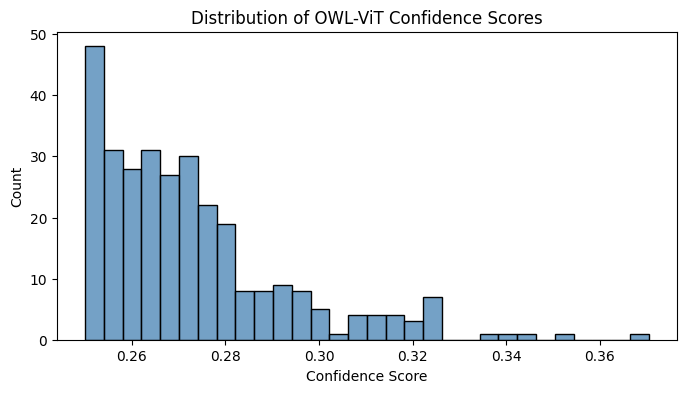

/tmp/ipykernel_424960/3838795036.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="crest")


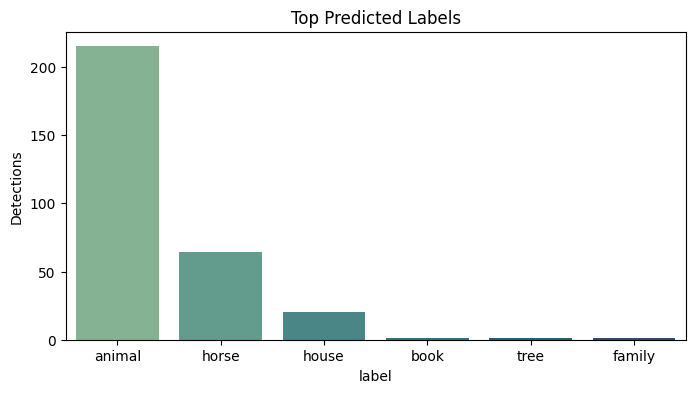

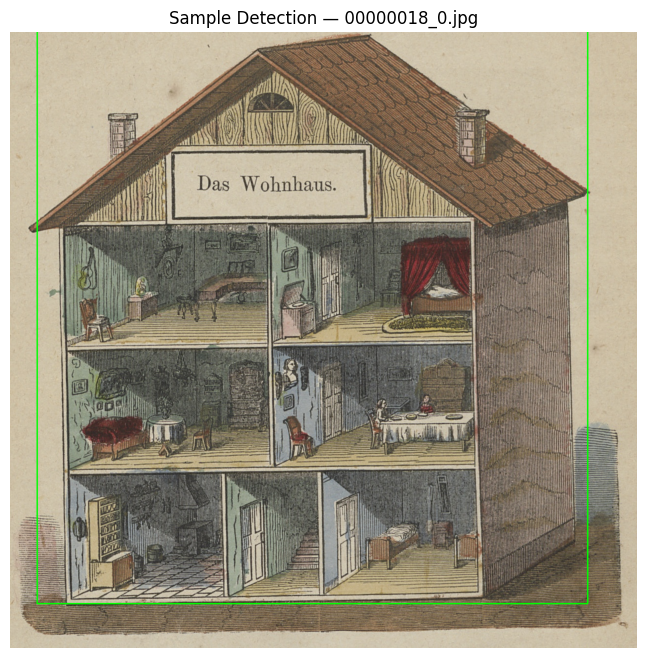

✅ Visualization complete.


In [1]:
#!/usr/bin/env python
# coding: utf-8

# # 📊 Pseudo-Label and OWL-ViT Results Analysis
# Brhanu Gebretsadik — November 2025

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

# --- Configuration ---
results_csv = "/home/brhanu/thesis_project/results/owlvit_results.csv"
image_root = "/home/brhanu/thesis_project/data/colibri/images/data"
pseudo_dir = "/home/brhanu/thesis_project/data/pseudo_labels"

# --- Load the data ---
df = pd.read_csv(results_csv)
print(f"Loaded {len(df)} detections")
df.head()

# ## 1️⃣ Confidence Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['score'], bins=30, color='steelblue')
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.title("Distribution of OWL-ViT Confidence Scores")
plt.show()

# ## 2️⃣ Label Frequency
label_counts = df['label'].value_counts()
plt.figure(figsize=(8,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="crest")
plt.ylabel("Detections")
plt.title("Top Predicted Labels")
plt.show()

# ## 3️⃣ Summary Statistics per Label
summary = (
    df.groupby("label")["score"]
      .agg(["count", "mean", "max", "min"])
      .sort_values("count", ascending=False)
)
summary.round(3)

# ## 4️⃣ Visualize Example Image with Pseudo-Labels

def draw_boxes(img_path, df_img):
    image = cv2.imread(img_path)
    if image is None:
        return None
    for _, row in df_img.iterrows():
        x1, y1, x2, y2 = map(int, [row["xmin"], row["ymin"], row["xmax"], row["ymax"]])
        label = f"{row['label']} {row['score']:.2f}"
        cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(image, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sample_img = df.sample(1).iloc[0]["image_path"]
sample_df = df[df["image_path"] == sample_img]
image = draw_boxes(sample_img, sample_df)
if image is not None:
    plt.figure(figsize=(10,8))
    plt.imshow(image)
    plt.title(f"Sample Detection — {os.path.basename(sample_img)}")
    plt.axis("off")
    plt.show()

# ## 5️⃣ (Optional) Compare to YOLOv8 Fine-Tuned Predictions
# Uncomment and update the path below if you already ran YOLO training.

# yolo_preds = "/home/brhanu/thesis_project/runs/detect/train/predictions.csv"
# if os.path.exists(yolo_preds):
#     ydf = pd.read_csv(yolo_preds)
#     merged = df.merge(ydf, on="image_path", suffixes=("_owlvit", "_yolo"))
#     sns.scatterplot(data=merged, x="score_owlvit", y="score_yolo", hue="label_owlvit")
#     plt.title("OWL-ViT vs YOLO Confidence Comparison")
#     plt.show()

print("✅ Visualization complete.")
